# Torneo GNN 2025–26 — Predicción de lipofilicidad molecular

**Equipo:** Neuronetes  
**Participantes:**  
- Aliss Maria Bejerano Kindelán  
- David Tamajón  

**Objetivo:** predecir la **lipofilicidad** de moléculas representadas como grafos usando **Graph Neural Networks (GNNs)**.

## 1. Enunciado y representación del problema

Cada **grafo representa una molécula**:

- **Nodos:** elementos químicos  
- **Aristas:** enlaces entre elementos  

Atributos del dataset:

- `x[?, 9]`: tensor con atributos de nodos (p.ej., peso atómico, orbitales sp2/sp3, carga relativa, etc.).  
  Cada grafo tiene número variable de nodos (mediana $\approx$ 27).
- `edge_index[2, ?]`: conectividad del grafo.  
  Cada grafo tiene número variable de aristas (mediana $\approx$ 60).
- `y[1]`: lipofilicidad del grafo (target de regresión).
- `nid[1]`: identificador de cada grafo. Se usa para **enviar** predicciones al servidor.
- `train_idx[3360]`: índices de grafos con etiqueta; se usan para entrenar/validar.
- `test_idx[840]`: índices de grafos **sin etiqueta para entrenamiento**; estos se evalúan en el torneo.

**Regla clave:** `test_idx` NO se usa para entrenar ni para validar. Solo para generar la solución final.

### 1.1. Configuración e instalación de dependencias

In [1]:
!pip install PyTorch_lightning
!pip install -q torch-geometric

In [2]:
# Core
import os
import os.path as osp
import json
import math
import random
from zipfile import ZipFile
from collections import Counter

# Numerical and data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Graph utilities
import networkx as nx

# ML utilities
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.loader import DataLoader
from torch_geometric.data import InMemoryDataset, download_url
from torch_geometric.utils.convert import from_networkx
from torch_geometric.utils import to_networkx
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv, GINConv,
    global_mean_pool, global_add_pool,
    JumpingKnowledge
)
from torch_geometric.nn.aggr import AttentionalAggregation
from torch_geometric.nn import GCNConv, JumpingKnowledge


## 1.2. Loading dataset

In [3]:
class TournamentDataset(InMemoryDataset):

    TORUNAMENT_URL = 'https://drive.upm.es/s/WTBtQ3HH2GjpGAi/download'

    def __init__(self, root, transform=None, pre_transform=None, pre_filter=None):
        super().__init__(root, transform, pre_transform, pre_filter)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)
        self.train_idx = torch.load(self.processed_paths[1], weights_only=False)
        self.test_idx = torch.load(self.processed_paths[2], weights_only=False)

    @property
    def raw_file_names(self):
        return ['nx_graphs.zip']

    @property
    def processed_file_names(self):
        return ['geometric_data_processed.pt', "train_idx.pt", "test_idx.pt"]

    @property
    def num_classes(self):
        return 1

    @property
    def num_features(self):
        return 9

    def download(self):
        download_url(self.TORUNAMENT_URL, self.raw_dir, filename='nx_graphs.zip')

    def process(self):

        with ZipFile(self.raw_paths[0], 'r') as zip_ref:
            zip_ref.extractall(self.raw_dir)

        data_list = []
        train_idx = []
        test_idx = []
        for f in os.listdir(osp.join(self.raw_dir, "nx_graphs")):
            G = nx.read_gml(osp.join(self.raw_dir, "nx_graphs", f))
            data = from_networkx(G)
            data.x = data.x.float()

            data.nid = torch.tensor([G.graph["molecule_id"]], dtype=torch.long)
            data_list.append(data)

            if G.graph["set"] == "training":
                data.y = torch.tensor([G.graph["y"]], dtype=torch.float)
                train_idx.append(G.graph["molecule_id"])
            else:
                data.y = torch.tensor([torch.nan], dtype=torch.float)
                test_idx.append(G.graph["molecule_id"])

        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]

        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        data_list.sort(key=lambda x: x.nid.item())

        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_paths[0])
        torch.save(train_idx, self.processed_paths[1])
        torch.save(test_idx, self.processed_paths[2])

Processing...
Done!


Number of molecules: 4200
Number of node attributes: 9
Example Graph: Data(x=[22, 9], edge_index=[2, 50], y=[1], molecule_id=[1], set='training', nid=[1])
Training set size: 3360
Test set size: 840
Trainning distribution: count    3360.000000
mean        2.200554
std         1.199276
min        -1.500000
25%         1.437500
50%         2.360000
75%         3.100000
max         4.500000
dtype: float64
Test distribution: Counter({'nan': 840})


Text(0.5, 1.0, 'Histogram of training labels')

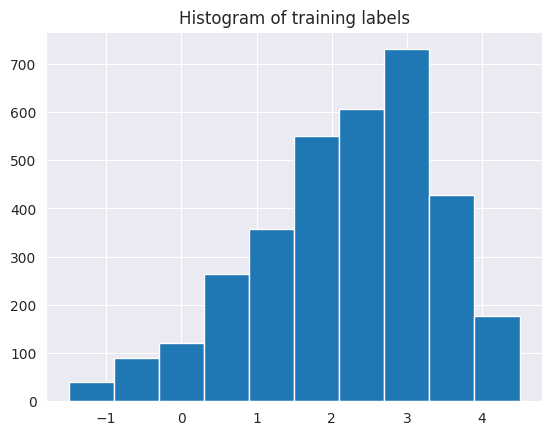

In [4]:
sns.set_style("darkgrid") # graficas

dataset = TournamentDataset(root='tournament')

print(f"Number of molecules: {len(dataset)}")
print(f"Number of node attributes: {dataset.num_features}")
print(f"Example Graph: {dataset[0]}")
print(f"Training set size: {len(dataset.train_idx)}")
print(f"Test set size: {len(dataset.test_idx)}")
print(f"Trainning distribution: {pd.Series([dataset[i].y.item() for i in dataset.train_idx]).describe()}")
print(f"Test distribution: {Counter([str(dataset[i].y.item()) for i in dataset.test_idx])}")

pd.Series([dataset[i].y.item() for i in dataset.train_idx]).hist()
plt.title("Histogram of training labels")

El histograma del conjunto de entrenamiento muestra:

- Distribución unimodal con mayor densidad entre 1.5 y 3.5.
- Rango amplio aproximadamente entre -1.5 y 4.5.
- Ligera asimetría hacia valores bajos.
- No se observa una distribución uniforme.

Esto indica que el problema corresponde a una regresión continua real,
con valores dispersos y sin concentración extrema en un único punto.

In [5]:
# Setup  seed
def seed_everything(seed=45):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(45)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1.1. Index and verifying

In [6]:
train_idx = np.array(dataset.train_idx)
test_idx  = np.array(dataset.test_idx)

print("Total graphs:", len(dataset))
print("Train graphs:", len(train_idx))
print("Test graphs:", len(test_idx))
print("Num node features:", dataset.num_features)

# ejemplo
g0 = dataset[train_idx[0]]
print("\nEjemplo grafo:")
print("x:", g0.x.shape)
print("edge_index:", g0.edge_index.shape)
print("y:", g0.y.shape if hasattr(g0, "y") and g0.y is not None else None)
print("nid:", g0.nid.shape if hasattr(g0, "nid") else None)

Total graphs: 4200
Train graphs: 3360
Test graphs: 840
Num node features: 9

Ejemplo grafo:
x: torch.Size([27, 9])
edge_index: torch.Size([2, 60])
y: torch.Size([1])
nid: torch.Size([1])


# 2. Métrica de evaluación

La tarea es **regresión**, y se evalúa mediante:

- **RMSE (Root Mean Squared Error)**: penaliza más los errores grandes y es la métrica estándar del torneo.

La selección del mejor modelo se realiza por **menor RMSE de validación**.

## 3. Análisis exploratorio de datos (EDA)

Objetivos del EDA:
1. Ver la distribución del tamaño de los grafos: **#nodos** y **#aristas**.
2. Analizar la distribución del target **y** (lipofilicidad).
3. Confirmar coherencia con el enunciado (medianas aproximadas esperadas).

Mediana nodos: 27.0
Mediana aristas: 60.0
y mean/std: 2.2005535715825055 1.1990975488955335


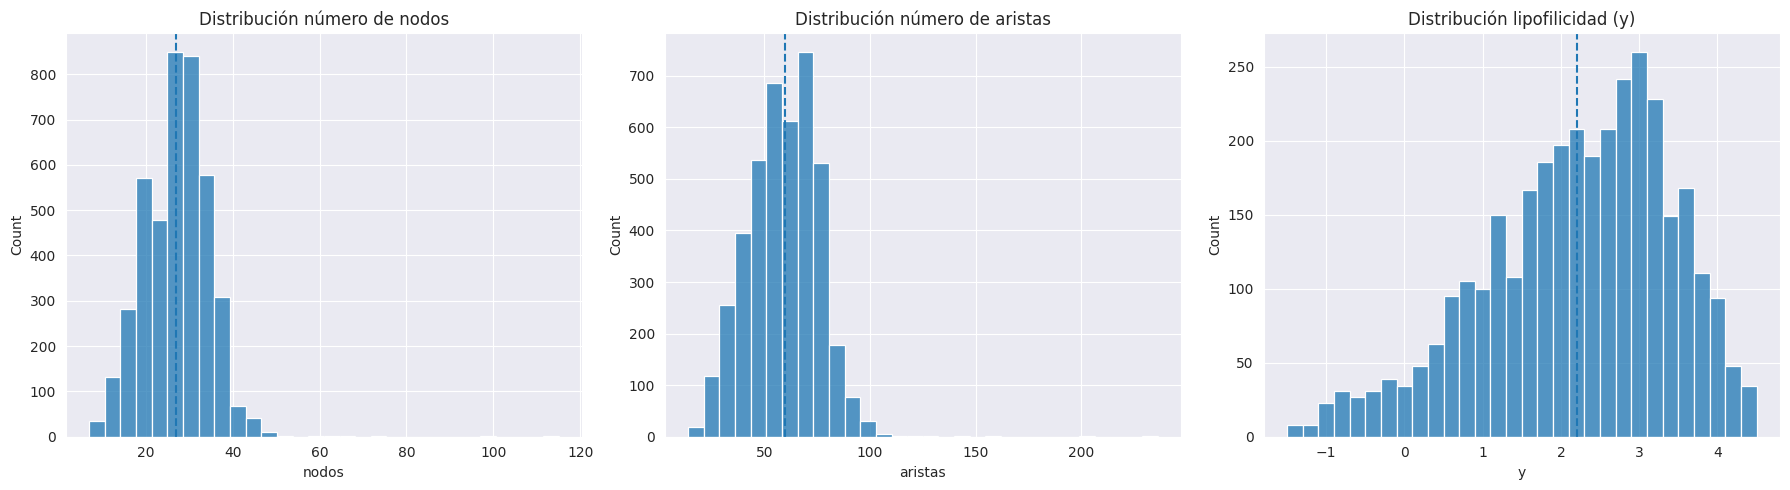

In [7]:
sns.set_style("darkgrid")

num_nodes = []
num_edges = []
ys = []

for i in range(len(dataset)):
    g = dataset[i]
    num_nodes.append(g.num_nodes)
    num_edges.append(g.edge_index.size(1))
    if hasattr(g, "y") and g.y is not None and not torch.isnan(g.y):
        ys.append(float(g.y.view(-1)[0]))

num_nodes = np.array(num_nodes)
num_edges = np.array(num_edges)
ys = np.array(ys) if len(ys) > 0 else None

print("Mediana nodos:", np.median(num_nodes))
print("Mediana aristas:", np.median(num_edges))
if ys is not None:
    print("y mean/std:", ys.mean(), ys.std())

# Plots
fig, axes = plt.subplots(1, 3 if ys is not None else 2, figsize=(18, 5))

# Nodos
sns.histplot(num_nodes, bins=30, ax=axes[0])
axes[0].axvline(np.median(num_nodes), linestyle="--")
axes[0].set_title("Distribución número de nodos")
axes[0].set_xlabel("nodos")

# Aristas
sns.histplot(num_edges, bins=30, ax=axes[1])
axes[1].axvline(np.median(num_edges), linestyle="--")
axes[1].set_title("Distribución número de aristas")
axes[1].set_xlabel("aristas")

# y
if ys is not None:
    sns.histplot(ys, bins=30, ax=axes[2])
    axes[2].axvline(np.mean(ys), linestyle="--")
    axes[2].set_title("Distribución lipofilicidad (y)")
    axes[2].set_xlabel("y")

plt.tight_layout()
plt.show()

**Del análisis exploratorio podemos decir lo siguiente:**

Distribución del número de nodos:
- La mayoría de las moléculas contienen entre 20 y 35 átomos,
con una mediana aproximada cercana a 27 nodos.
- La distribución es unimodal con ligera cola hacia grafos más grandes,
lo que indica variabilidad estructural moderada.
- Esto confirma que el modelo debe ser capaz de manejar
grafos de tamaño variable.

Distribución de aristas:
 - El número de enlaces por molécula se concentra entre 40 y 90,
con una mediana cercana a 60.
 - Esto sugiere grafos con conectividad química típica, sin estructuras extremadamente densas ni excesivamente dispersas.

El grado medio estimado (2E/N) es aproximadamente 4–5,
lo que es coherente con estructuras moleculares químicamente plausibles.

 Lipofilicidad:
- La lipofilicidad presenta una distribución continua unimodal,
con mayor concentración entre 1 y 3.5.
- Los valores extremos (muy bajos o muy altos) son menos frecuentes,
lo que podría dificultar la predicción en esos rangos.
- La media del target ($\approx$ 2.2) no está centrada en cero,
lo que abre la posibilidad de normalización como mejora futura.



## 3.1. Visualización estructural de una molécula

Se representa una molécula del dataset en tres formas:

1. Estructura base del grafo.
2. Coloreado por grado del nodo (conectividad).
3. Coloreado según la primera feature del nodo.

Se observa variabilidad en conectividad y atributos,
lo que justifica el uso de arquitecturas GNN capaces
de modelar información estructural y de atributos simultáneamente.

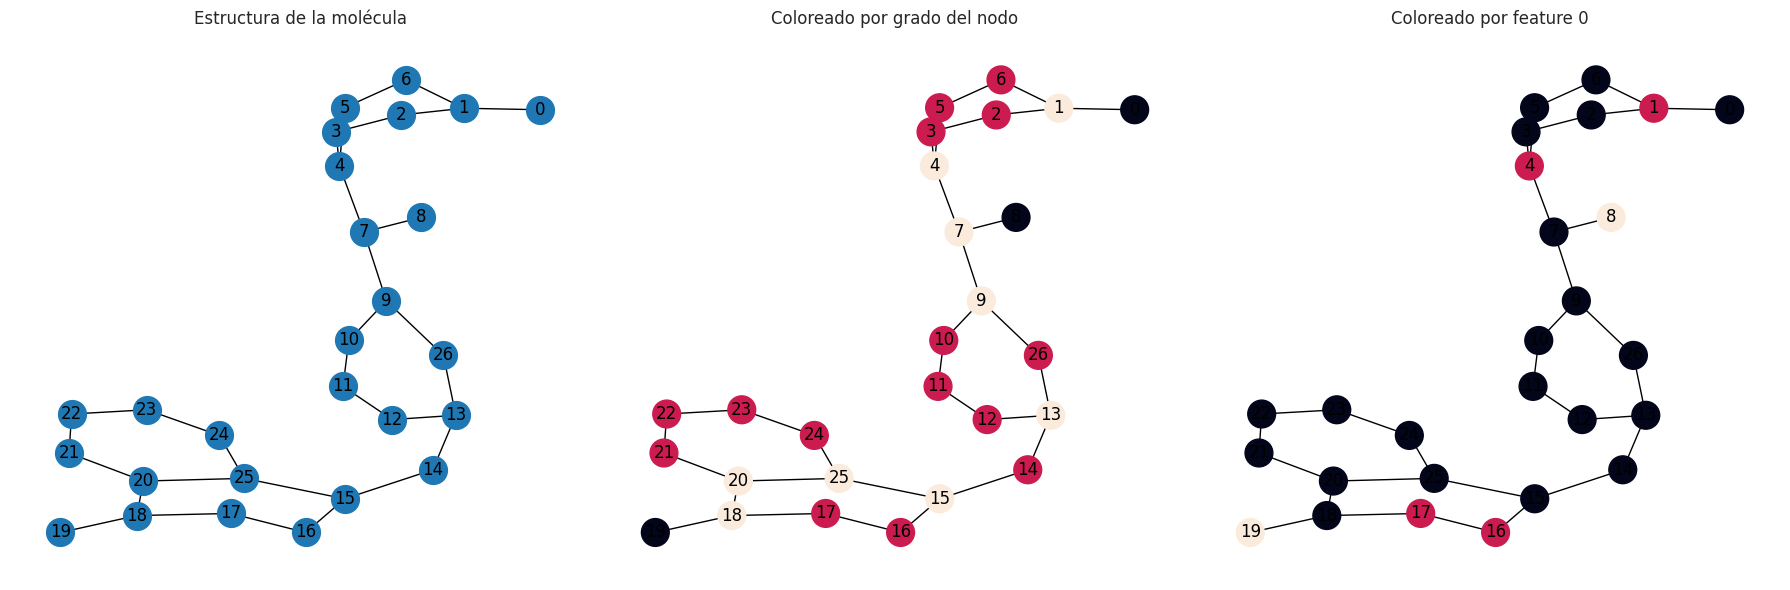

In [8]:
# Seleccionamos una molécula
example = dataset[dataset.train_idx[0]]

# Convertimos a NetworkX
G = to_networkx(example, to_undirected=True)

# Layout fijo
pos = nx.spring_layout(G, seed=45)

# Figura
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafo base
nx.draw(
    G, pos,
    ax=axes[0],
    with_labels=True,
    node_size=400
)
axes[0].set_title("Estructura de la molécula")

# Coloreado por grado
degrees = dict(G.degree())
deg_colors = [degrees[n] for n in G.nodes()]

nx.draw(
    G, pos,
    ax=axes[1],
    node_color=deg_colors,
    with_labels=True,
    node_size=400
)
axes[1].set_title("Coloreado por grado del nodo")

# Coloreado por feature
feature_0 = example.x[:, 0].numpy()

nx.draw(
    G, pos,
    ax=axes[2],
    node_color=feature_0,
    with_labels=True,
    node_size=400
)
axes[2].set_title("Coloreado por feature 0")

plt.tight_layout()
plt.show()

## 4. Models

### 4.1 Baseline — GCN añadiendo Global Mean Pooling

Arquitectura baseline:
- Capas `GCNConv` + BatchNorm + ReLU + Dropout
- Pooling global: `global_mean_pool`
- Capa final lineal para regresión

Se utiliza como referencia para medir mejoras de otras arquitecturas.

In [9]:
class GCNGraph(nn.Module):
    def __init__(self, num_features, num_classes=1,
                 hidden_channels=64, n_layers=3, dropout=0.2):
        super().__init__()

        self.n_layers = n_layers
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        # Primera capa
        self.convs.append(GCNConv(num_features, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Capas intermedias
        for _ in range(n_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))

        # Cabeza final (regresión)
        self.lin = nn.Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch

        # Message passing
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # Pooling global
        x = global_mean_pool(x, batch)

        # Regresión final
        x = self.lin(x)

        return x.view(-1)

### 4.2 Modelos alternativos evaluados

Se probaron arquitecturas típicas para grafos moleculares:

- **GIN + mean pooling**: fuerte en tareas tipo MoleculeNet.
- **GraphSAGE + mean pooling**: agregación flexible y estable.
- **GAT + mean pooling**: introduce atención en la agregación.
- **GCN + Jumping Knowledge + Attention pooling**: combina múltiples profundidades + pooling atencional.

In [10]:
# Otras arquitecturas

# GIN + mean pooling (según la literatura es fuerte en MoleculeNet)
class GINMean(nn.Module):
    def __init__(self, in_dim, hidden=128, layers=5, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for i in range(layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_mean_pool(x, batch)
        return self.head(g).view(-1)


# GraphSAGE adicionada a mean pooling (rápida y sólida)
class SAGeMean(nn.Module):
    def __init__(self, in_dim, hidden=128, layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.convs.append(SAGEConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(layers - 1):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_mean_pool(x, batch)
        return self.head(g).view(-1)


# GAT mean pooling (atención en aristas)
class GATMean(nn.Module):
    def __init__(self, in_dim, hidden=64, heads=4, layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # Primera capa
        self.convs.append(GATConv(in_dim, hidden, heads=heads, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden * heads))

        for _ in range(layers - 1):
            self.convs.append(GATConv(hidden * heads, hidden, heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden * heads))

        self.head = nn.Sequential(
            nn.Linear(hidden * heads, hidden * heads),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * heads, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        g = global_mean_pool(x, batch)
        return self.head(g).view(-1)


# GCN  JumpingKnowledge
class GCN_JK_Att(nn.Module):
    def __init__(self, in_dim, hidden=64, layers=4, dropout=0.2, jk_mode="cat"):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        self.convs.append(GCNConv(in_dim, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(layers - 1):
            self.convs.append(GCNConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))

        self.jk = JumpingKnowledge(mode=jk_mode)
        jk_out = hidden * layers if jk_mode == "cat" else hidden

        # Pooling atencional
        self.pool = AttentionalAggregation(gate_nn=nn.Linear(jk_out, 1))

        self.head = nn.Sequential(
            nn.Linear(jk_out, jk_out),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(jk_out, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        xs = []
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            xs.append(x)

        h = self.jk(xs)
        g = self.pool(h, batch)
        return self.head(g).view(-1)

### 4.2.1. Implementación modular de arquitecturas

Se implementó una función tipo "factory" que permite instanciar
diferentes arquitecturas GNN (GCN, GIN, GraphSAGE, GAT y una variante con Jumping Knowledge + pooling atencional) a partir de un identificador textual.

Esto facilita:

- La comparación sistemática entre modelos
- La integración con K-Fold
- La reproducibilidad experimental
- La reducción de código duplicado

Cada arquitectura fue evaluada bajo el mismo protocolo de validación.

In [11]:
def make_model(model_name, dataset):
    if model_name == "GCN_baseline":
        return GCNGraph(
            num_features=dataset.num_features,
            num_classes=1,
            hidden_channels=64,
            n_layers=3,
            dropout=0.2
        )

    elif model_name == "GIN_mean":
        return GINMean(in_dim=dataset.num_features, hidden=128, layers=5, dropout=0.2)

    elif model_name == "SAGE_mean":
        return SAGeMean(in_dim=dataset.num_features, hidden=128, layers=4, dropout=0.2)

    elif model_name == "GAT_mean":
        return GATMean(in_dim=dataset.num_features, hidden=64, heads=4, layers=3, dropout=0.2)

    elif model_name == "GCN_JK_Att":
        return GCN_JK_Att(in_dim=dataset.num_features, hidden=64, layers=4, dropout=0.2, jk_mode="cat")

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

### 4.2.2. Entrenamiento de un fold con *Early Stopping*

Se define la función `train_one_fold`, encargada de entrenar una arquitectura GNN en el subconjunto de entrenamiento de un fold y evaluar su rendimiento en el subconjunto de validación correspondiente.

  -  ### Métrica de evaluación

Se utiliza **RMSE** como métrica principal de validación, ya que penaliza más los errores grandes y es coherente con el criterio de evaluación del torneo (basado en error cuadrático).

 -  ### Configuración del entrenamiento

Se emplea:

   - **Optimizador:** AdamW (incluye regularización mediante *weight decay*).
   - **Función de pérdida:** `SmoothL1Loss` (Huber), más robusta ante outliers que MSE.
   - **Scheduler:** `ReduceLROnPlateau`, que reduce el *learning rate* cuando el **RMSE de validación** deja de mejorar.
   - **Gradient clipping:** para estabilizar el entrenamiento y evitar explosión de gradientes.
   - **Mini-batches de grafos:** mediante `DataLoader`, agregando múltiples moléculas por batch.


- ### Procedimiento por epoch

En cada epoch:

  - a) Entrenamiento del modelo sobre los batches del conjunto de entrenamiento.
  - b) Cálculo de la pérdida media de entrenamiento.
 - c) Evaluación en validación sin gradientes (`torch.no_grad()`).
 - d) Agregación de predicciones y cálculo del **RMSE global** en validación.
 - e) Actualización del scheduler con `val_rmse`.
 - f) Aplicación de *early stopping*: si `val_rmse` no mejora durante `patience` epochs, se detiene el entrenamiento.

Se conserva el mejor estado del modelo (checkpoint en memoria `best_state`) correspondiente al **menor RMSE de validación** observado.

-  ### Salida de la función

La función devuelve:

- El modelo con los mejores pesos del fold.
- El mejor RMSE alcanzado en validación.
- El historial de entrenamiento (`epoch`, `train_loss`, `val_rmse`) para posterior visualización.

In [12]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def train_one_fold(model_name, train_ids, val_ids,
                   max_epochs=400, patience=40,
                   lr=1e-3, weight_decay=5e-4,
                   batch_size=256):

    train_loader = DataLoader(dataset[train_ids], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(dataset[val_ids],   batch_size=batch_size, shuffle=False)

    # factory
    model = make_model(model_name, dataset).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.SmoothL1Loss()  # Huber (robusta)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=10
    )

    best_rmse = float("inf")
    best_state = None
    wait = 0
    history = []  # (epoch, train_loss, val_rmse)

    for epoch in range(1, max_epochs + 1):
        #train
        model.train()
        total_loss, n = 0.0, 0

        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            y_true = data.y.view(-1).float()
            y_pred = model(data).view(-1)

            loss = criterion(y_pred, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            optimizer.step()

            bs = data.num_graphs
            total_loss += loss.item() * bs
            n += bs

        train_loss = total_loss / max(n, 1)

        #val
        model.eval()
        y_true_all, y_pred_all = [], []

        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                y_true = data.y.view(-1).float().cpu().numpy()
                y_pred = model(data).view(-1).cpu().numpy()
                y_true_all.append(y_true)
                y_pred_all.append(y_pred)

        y_true_all = np.concatenate(y_true_all)
        y_pred_all = np.concatenate(y_pred_all)
        val_rmse = rmse(y_true_all, y_pred_all)

        scheduler.step(val_rmse)
        history.append((epoch, train_loss, val_rmse))

        # early stopping
        if val_rmse < best_rmse - 1e-5:
            best_rmse = val_rmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f"{model_name} | epoch {epoch:03d} | tr_loss={train_loss:.4f} | val_rmse={val_rmse:.4f} | best={best_rmse:.4f} | wait={wait}")

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, best_rmse, history

## 5. Entrenamiento y validación (K-Fold Cross-Validation)

Para estimar el rendimiento de forma robusta y reducir la dependencia de una única partición,
se aplica **validación cruzada K-Fold (K=5)** sobre el conjunto etiquetado `train_idx`.

En cada fold:
- Se entrena con 4/5 de los grafos etiquetados.
- Se valida con 1/5 restante.
- Se reporta el **mejor RMSE de validación** alcanzado (early stopping).

Configuración de entrenamiento (constante para todas las arquitecturas):
- **Optimizador:** AdamW (con `weight_decay`).
- **Pérdida:** `SmoothL1Loss` (Huber), robusta ante outliers.
- **Scheduler:** `ReduceLROnPlateau` sobre `val_rmse`.
- **Gradient clipping** para estabilizar el entrenamiento.
- **Early stopping** basado en RMSE de validación.

La comparación final entre modelos se resume como:

**RMSE mean ± std** (media y desviación estándar en los 5 folds).

In [13]:
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def train_one_fold_generic(train_ids, val_ids, model_name,
                           max_epochs=300, patience=35,
                           lr=1e-3, weight_decay=5e-4,
                           batch_size=256):
    train_loader = DataLoader(dataset[train_ids], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(dataset[val_ids],   batch_size=batch_size, shuffle=False)

    #factory
    model = make_model(model_name, dataset).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = torch.nn.SmoothL1Loss()
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10)

    best = float("inf")
    best_state = None
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss, n = 0.0, 0

        for data in train_loader:
            data = data.to(device)
            opt.zero_grad()
            y = data.y.view(-1).float()
            p = model(data).view(-1)
            loss = crit(p, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()

            bs = data.num_graphs
            total_loss += loss.item() * bs
            n += bs

        tr_loss = total_loss / max(n, 1)

        model.eval()
        ys, ps = [], []
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                ys.append(data.y.view(-1).float().cpu().numpy())
                ps.append(model(data).view(-1).cpu().numpy())

        y_true = np.concatenate(ys)
        y_pred = np.concatenate(ps)
        val = rmse(y_true, y_pred)

        sch.step(val)
        history.append((epoch, tr_loss, val))

        if val < best - 1e-5:
            best = val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f"{model_name} | epoch {epoch:03d} | tr_loss={tr_loss:.4f} | val_rmse={val:.4f} | best={best:.4f} | wait={wait}")

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    model.to(device)
    return model, best, history

def kfold_run(model_name, K=5):
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    models, scores, histories = [], [], []

    for fold, (tr, va) in enumerate(kf.split(train_idx), start=1):
        tr_ids = train_idx[tr]
        va_ids = train_idx[va]

        print(f"\n----- {model_name} | FOLD {fold}/{K} -----")
        m, s, h = train_one_fold_generic(tr_ids, va_ids, model_name=model_name)
        models.append(m); scores.append(s); histories.append(h)
        print(f"{model_name} fold {fold} best RMSE: {s:.4f}")

    scores = np.array(scores)
    print(f"\n{model_name}: RMSE mean ± std = {scores.mean():.4f} ± {scores.std():.4f}")
    return models, scores, histories

In [14]:
model_names = ["GCN_baseline", "GIN_mean", "SAGE_mean", "GAT_mean", "GCN_JK_Att"]

results = {}

for name in model_names:
    models, scores, histories = kfold_run(name, K=5)
    results[name] = {
        "models": models,
        "scores": scores,
        "histories": histories
    }


----- GCN_baseline | FOLD 1/5 -----
GCN_baseline | epoch 001 | tr_loss=1.5886 | val_rmse=2.4056 | best=2.4056 | wait=0
GCN_baseline | epoch 025 | tr_loss=0.4622 | val_rmse=1.1286 | best=1.0853 | wait=3
GCN_baseline | epoch 050 | tr_loss=0.3975 | val_rmse=0.9991 | best=0.9991 | wait=0
GCN_baseline | epoch 075 | tr_loss=0.3681 | val_rmse=0.9433 | best=0.9288 | wait=6
GCN_baseline | epoch 100 | tr_loss=0.3398 | val_rmse=0.9599 | best=0.8787 | wait=1
GCN_baseline | epoch 125 | tr_loss=0.3209 | val_rmse=0.9100 | best=0.8620 | wait=9
GCN_baseline | epoch 150 | tr_loss=0.3109 | val_rmse=0.8738 | best=0.8346 | wait=4
GCN_baseline | epoch 175 | tr_loss=0.2939 | val_rmse=1.2012 | best=0.8130 | wait=9
GCN_baseline | epoch 200 | tr_loss=0.2853 | val_rmse=0.8082 | best=0.8014 | wait=12
GCN_baseline | epoch 225 | tr_loss=0.2879 | val_rmse=0.8051 | best=0.7925 | wait=7
GCN_baseline | epoch 250 | tr_loss=0.2837 | val_rmse=0.7906 | best=0.7906 | wait=0
GCN_baseline | epoch 275 | tr_loss=0.2825 | val_r

## 5.1. Resultados (K-Fold, K=5)

Se evaluaron 5 arquitecturas GNN mediante validación cruzada 5-fold usando RMSE como métrica.

**Resumen (RMSE mean ± std):**
- **SAGE_mean 0.671470 ± 0.021105**
- GIN_mean	0.688448	± 0.020781
- GAT_mean	0.752738	 ± 0.024428
- GCN_JK_Att	0.762159 ±  	0.037480
- GCN_baseline	0.808683	±  0.023844

**Modelo seleccionado:** **SAGE_mean**, al obtener el menor RMSE medio.
GIN_mean resulta muy competitivo y presenta menor desviación estándar, indicando un comportamiento más estable entre folds, aunque con un RMSE medio ligeramente superior.

In [15]:
summary_df = pd.DataFrame([
    {
        "Modelo": name,
        "RMSE_mean": float(results[name]["scores"].mean()),
        "RMSE_std": float(results[name]["scores"].std())
    }
    for name in model_names
]).sort_values("RMSE_mean").reset_index(drop=True)

summary_df

,Modelo,RMSE_mean,RMSE_std
0,SAGE_mean,0.671470,0.021105
1,GIN_mean,0.688448,0.020781
2,GAT_mean,0.752738,0.024428
3,GCN_JK_Att,0.762159,0.037480
4,GCN_baseline,0.808683,0.023844


| Modelo           |Consideraciones |
|------------------|-------------------|
| **SAGE_mean**    | Mejor rendimiento medio. Agregación flexible y buena generalización en grafos de tamaño variable. |
| GIN_mean         | Muy competitivo. Alta expresividad (MLP interno) para distinguir estructuras moleculares. |
| GCN_JK_Att       |Mejora sobre GCN simple combinando múltiples profundidades (JK) + pooling atencional, pero no alcanza GIN/SAGE. |
| GAT_mean         | Atención en aristas no aporta mejora neta en este dataset frente a GIN/SAGE. |
| GCN_baseline    | Baseline GCN + mean pooling. Menor capacidad para capturar interacciones químicas complejas. |

**Modelo seleccionado:** **GraphSAGE (SAGE_mean)** por menor RMSE medio en validación cruzada.

## Interpretación de resultados

1. **Baseline (GCN)**: obtiene un RMSE medio $\approx$ 0.80. La agregación tipo GCN y el pooling por media proporcionan una referencia sólida, pero su expresividad puede ser insuficiente para capturar relaciones estructurales finas en grafos moleculares.

2. **GIN** mejora de forma clara (RMSE $\approx$  0.69). Esta mejora es coherente con la alta capacidad representacional de GIN, donde cada capa utiliza un MLP interno para modelar transformaciones no lineales más ricas.

3. **GraphSAGE** obtiene el mejor rendimiento (RMSE $\approx$  0.67). Su esquema de agregación es flexible y suele generalizar bien en grafos con tamaños variables, lo que encaja con el dataset (número de nodos/aristas variable por molécula).

4. **GAT** y **GCN con Jumping Knowledge + attention pooling** mejoran frente al baseline en algunos folds, pero **no superan** a GIN/SAGE. Esto sugiere que, en este problema, la ganancia principal proviene de la **expresividad de la función de agregación** (GIN/SAGE) más que de introducir atención en aristas o pooling atencional.

5. La validación cruzada **K-Fold** permite comparar arquitecturas de manera robusta, reduciendo la dependencia de un único split train/validation y proporcionando RMSE medio ± desviación estándar.

## 6. Resultados y comparación de modelos

Se comparan modelos usando el mismo protocolo de validación (K-Fold) y la misma métrica (RMSE).
El modelo ganador se elige por el menor **RMSE medio**.

Además, se incluyen:
- Boxplots por arquitectura
- RMSE por fold
- Curvas de aprendizaje (val RMSE vs epoch)

## 6.1. Selección del fold para visualización
A la hora de visualizar las curvas de entrenamiento y validación, seleccionamos el fold según los siguientes criterios:

1. **Fold Mínimo**:  
   $$k^* = \arg\min_k RMSE_k$$  
   *Muestra el mejor caso observado, pero puede introducir un **sesgo optimista**, ya que el mínimo tiende a ser menor que el error esperado real.*

2. **Fold Representativo (Seleccionado)**:  
   $$k^* = \arg\min_k |RMSE_k - \overline{RMSE}|$$  
   *Este criterio selecciona el fold cuyo RMSE está **más cercano al promedio**, proporcionando una visualización más **representativa** del comportamiento típico del modelo y evitando el "cherry-picking".*

---

> **Nota:** En este trabajo se utiliza el **fold representativo** para las gráficas, mientras que la selección del mejor modelo se basa en el $\overline{RMSE}$ y su desviación estándar a través de todo el proceso de K-Fold.

In [16]:
best_model = summary_df.loc[0, "Modelo"]
scores = results[best_model]["scores"]
print("Mejor modelo:", best_model)
print("RMSE mean ± std:", float(scores.mean()), "±", float(scores.std()))

Mejor modelo: SAGE_mean
RMSE mean ± std: 0.6714704625966832 ± 0.021105390039535623


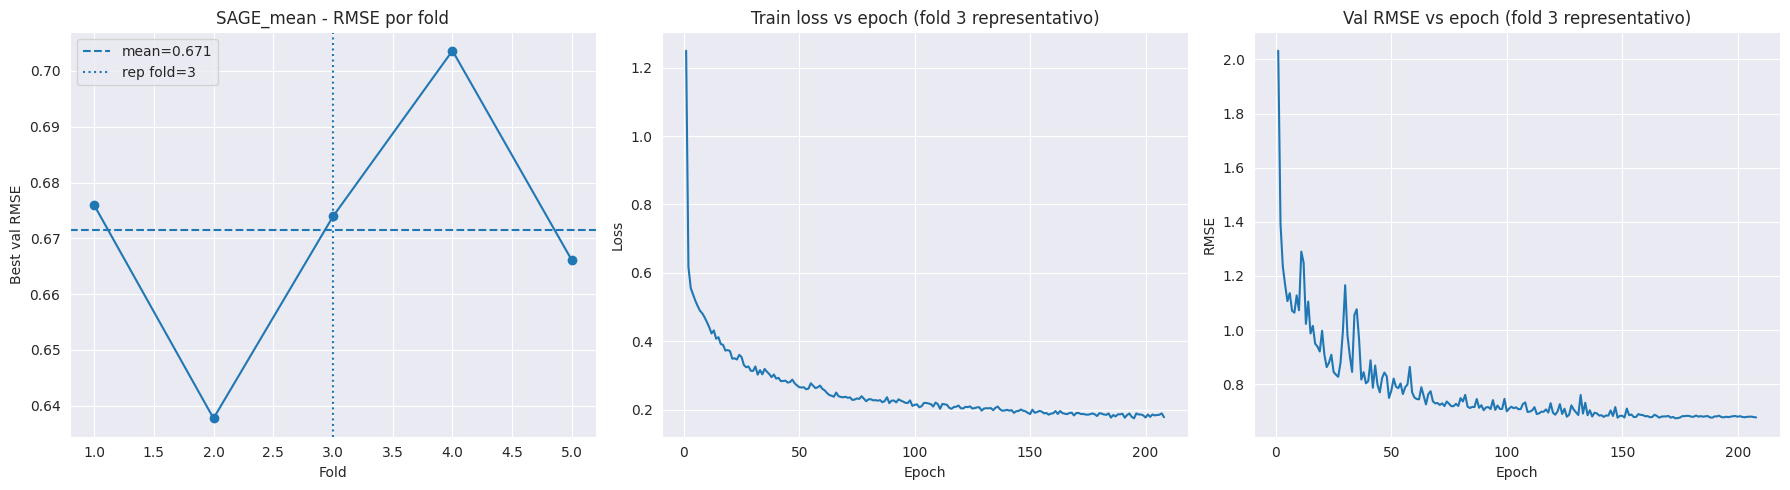

Mejor modelo: SAGE_mean
RMSE mean ± std: 0.6714704625966832 ± 0.021105390039535623
Fold representativo: 3 | RMSE: 0.6739260395062268


In [17]:
# best model
best_model = summary_df.loc[0, "Modelo"]

# Scores por fold
scores = results[best_model]["scores"]  # array/list de tamaño K
scores = np.array(scores, dtype=float)

# Fold representativo es el más cercano a la media
mean_rmse = scores.mean()
rep_fold = int(np.argmin(np.abs(scores - mean_rmse)))

# Historial del fold representativo
hist = results[best_model]["histories"][rep_fold]

epochs = [e for (e, tr, va) in hist]
train_losses = [tr for (e, tr, va) in hist]
val_rmses = [va for (e, tr, va) in hist]

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE por fold
axes[0].plot(range(1, len(scores)+1), scores, marker="o")
axes[0].axhline(mean_rmse, linestyle="--", label=f"mean={mean_rmse:.3f}")
axes[0].axvline(rep_fold+1, linestyle=":", label=f"rep fold={rep_fold+1}")
axes[0].set_title(f"{best_model} - RMSE por fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Best val RMSE")
axes[0].legend()

# Train loss vs epoch
axes[1].plot(epochs, train_losses)
axes[1].set_title(f"Train loss vs epoch (fold {rep_fold+1} representativo)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

# Val RMSE vs epoch
axes[2].plot(epochs, val_rmses)
axes[2].set_title(f"Val RMSE vs epoch (fold {rep_fold+1} representativo)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

print("Mejor modelo:", best_model)
print("RMSE mean ± std:", float(scores.mean()), "±", float(scores.std()))
print("Fold representativo:", rep_fold+1, "| RMSE:", float(scores[rep_fold]))

## 6.2. Comparación visual global de arquitecturas

- Izquierda: distribución del RMSE en los 5 folds.
- Centro: estabilidad del rendimiento entre folds.
- Derecha: dinámica de convergencia (fold 1 como ejemplo).

Se observa que SAGE_mean presenta menor RMSE medio,
mientras que GCN_baseline muestra mayor error.

/tmp/ipython-input-6953/2051867695.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data, labels=names, vert=True, showmeans=True)


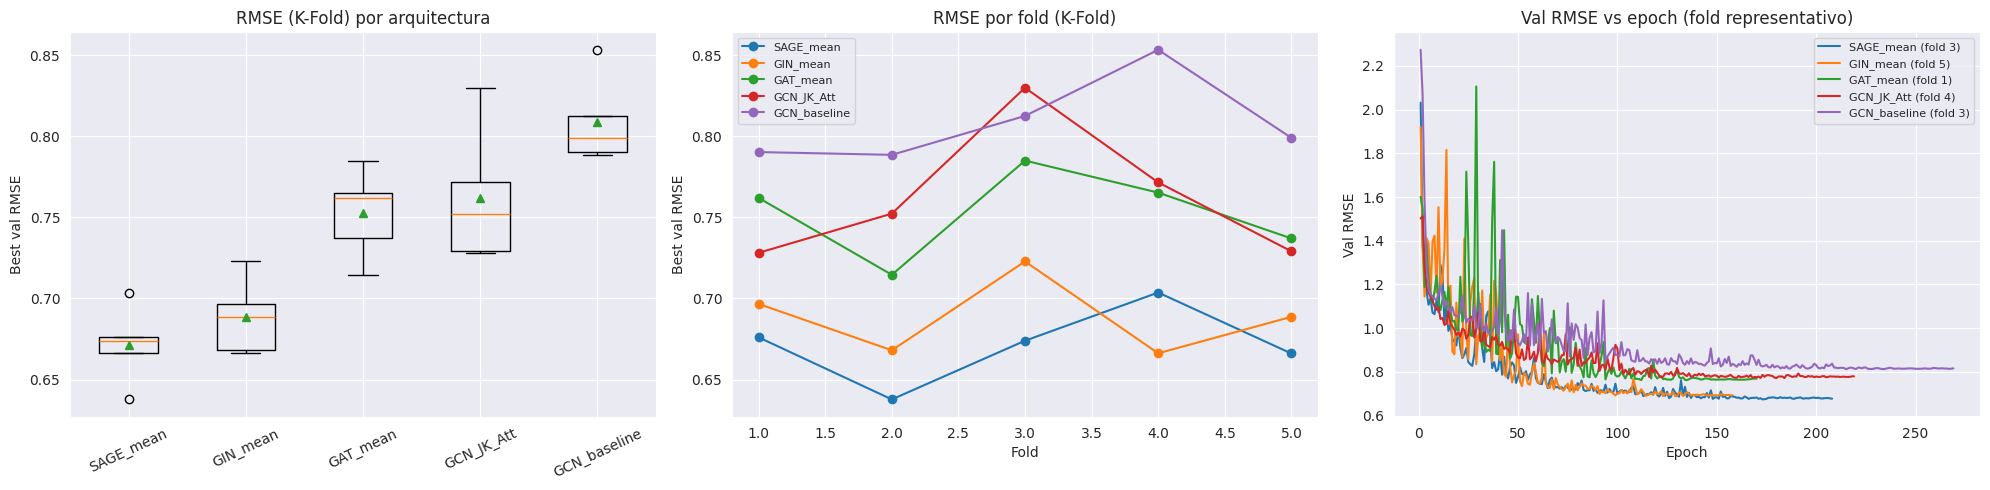

In [18]:
# Ordenamos modelos por RMSE medio (de mejor a peor)
names = sorted(results.keys(), key=lambda n: np.mean(results[n]["scores"]))
data  = [results[n]["scores"] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Boxplot por arquitectura
axes[0].boxplot(data, labels=names, vert=True, showmeans=True)
axes[0].set_title("RMSE (K-Fold) por arquitectura")
axes[0].set_ylabel("Best val RMSE")
axes[0].tick_params(axis='x', rotation=25)

# RMSE por fold (líneas)
for n in names:
    s = np.array(results[n]["scores"], dtype=float)
    axes[1].plot(range(1, len(s) + 1), s, marker="o", label=n)

axes[1].set_title("RMSE por fold (K-Fold)")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Best val RMSE")
axes[1].legend(fontsize=8)

# Curvas aprendizaje (fold representativo)
for n in names:
    s = np.array(results[n]["scores"], dtype=float)
    mean_s = s.mean()
    rep_fold = int(np.argmin(np.abs(s - mean_s)))  # fold más cercano a la media

    hist = results[n]["histories"][rep_fold]
    epochs = [h[0] for h in hist]
    val_rmse = [h[2] for h in hist]

    axes[2].plot(epochs, val_rmse, label=f"{n} (fold {rep_fold+1})")

axes[2].set_title("Val RMSE vs epoch (fold representativo)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Val RMSE")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Generación de solución para el torneo (JSON)

La solución se envía como un JSON con:
- lista de `nid`
- lista de predicciones `y`

Se recomienda generar predicción mediante **ensemble** (promedio de modelos de los folds) para mejorar generalización.

## 7.1. Enfoque: *Ensemble* con $K$ modelos entrenados en K-Fold

Para mejorar la robustez de la solución, implementamos un *ensemble* basado en la estrategia de validación cruzada:

* **Entrenamiento**: Se entrenan $K$ modelos independientes (uno por cada fold) utilizando la arquitectura seleccionada.
* **Inferencia**: Cada modelo produce una predicción $\hat{y}_k$ para cada grafo del conjunto de test.
* **Agregación**: La predicción final se obtiene promediando las $K$ predicciones individuales:

$$\hat{y}_{final} = \frac{1}{K}\sum_{k=1}^{K} \hat{y}_k$$

> **Motivación:** El promedio de modelos (Ensemble) reduce la varianza y suele mejorar la generalización, ya que compensa los posibles sesgos de una única partición de datos y suaviza las predicciones inestables.






### 7.2. Formato de salida requerido

El resultado se exporta en un archivo `test_predictions.json` que contiene dos listas alineadas:
* `nid`: Identificadores de grafos del test (manteniendo el orden original).
* `y`: Predicciones finales (valores tipo float).

**Ejemplo de estructura JSON:**

```json
{
  "nid": [1001, 1002, 1003, "..."],
  "y": [0.542, -1.231, 2.105, "..."]
}

In [19]:
# el mejor modelo y sus modelos por fold
best_model = summary_df.loc[0, "Modelo"]
fold_models = results[best_model]["models"]

# DataLoader de test
test_loader = DataLoader(dataset[test_idx], batch_size=256, shuffle=False)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

for m in fold_models:
    m.eval()
    m.to(device)

pred_rows = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        # Predicciones por modelo (K folds) (K, batch_size)
        preds = []
        for m in fold_models:
            preds.append(m(data).view(-1).detach().cpu().numpy())

        # Promedio ensemble
        yhat = np.mean(np.stack(preds, axis=0), axis=0)

        # NIDs del batch
        nids = data.nid.view(-1).detach().cpu().numpy().astype(int)

        for nid, y in zip(nids, yhat.astype(float)):
            pred_rows.append({"nid": int(nid), "y": float(y)})

df_predictions = (
    pd.DataFrame(pred_rows)
      .sort_values("nid")
      .reset_index(drop=True)
)

# checks
print("Best model used:", best_model)
print("Rows predicted:", len(df_predictions), "| Unique nids:", df_predictions["nid"].nunique())
print("First/last nid:", df_predictions["nid"].iloc[0], df_predictions["nid"].iloc[-1])

# Guardar JSON con el formato pedido
file_path = "test_predictions.json"
payload = {
    "nid": df_predictions["nid"].tolist(),
    "y": df_predictions["y"].tolist()
}

with open(file_path, "w") as f:
    json.dump(payload, f, indent=4)

print("Saved:", file_path)
df_predictions.head()

Best model used: SAGE_mean
Rows predicted: 840 | Unique nids: 840
First/last nid: 6 4199
Saved: test_predictions.json


,nid,y
0,6,3.451140
1,9,1.380305
2,15,0.255301
3,18,2.782423
4,20,-0.461271


## 8. Evaluación offline con `test_labels.csv`
 `test_labels.csv` se usa únicamente para:
- verificar localmente el pipeline
- estimar RMSE offline

**No se utiliza para entrenar ni para seleccionar hiperparámetros**, para evitar data leakage.
La selección del modelo se realiza únicamente con K-Fold sobre `train_idx`.

In [ ]:
labels_path = "test_labels.csv"
labels = pd.read_csv(labels_path)          #
preds = df_predictions.rename(columns={"nid": "id"})
merged = labels.merge(preds, on="id", how="inner")

rmse_test = math.sqrt(mean_squared_error(merged["label"].values, merged["y"].values))
print("Offline TEST RMSE:", rmse_test)
print("Matched rows:", len(merged), "of", len(labels))
merged.head()

## 8. Análisis de residuos (modelo ganador)

El RMSE resume el error medio, pero no indica **cómo** y **dónde** se equivoca el modelo. Para caracterizar el comportamiento del modelo más allá del valor global, analizamos los **residuos**:

$$e_i = \hat{y}_i - y_i$$

Donde $y_i$ es el valor real (etiqueta) y $\hat{y}_i$ es la predicción del modelo.



### 8.1. Objetivos del análisis

Para una evaluación profunda, nos centramos en los siguientes puntos clave:

* **Calibración (True vs Pred):** Verificamos si los puntos se alinean cerca de la diagonal $y = \hat{y}$.
* **Sesgo (Bias):** Si $\mathbb{E}[e] \neq 0$, el modelo presenta una tendencia sistemática a sobreestimar ($e > 0$) o subestimar ($e < 0$) los valores.
* **Distribución de residuos:** Analizamos el histograma de $e$ para detectar asimetrías, colas pesadas o valores atípicos (*outliers*).
* **Heterocedasticidad:** Graficamos los residuos frente al valor real para comprobar si la varianza del error es constante o si el modelo es menos preciso en rangos específicos del target.
* **Identificación de Outliers:** Localizamos las moléculas con mayor error absoluto para investigar posibles anomalías en sus grafos.
* **Error por rango de $y$:** Calculamos métricas (RMSE/MAE) por intervalos para determinar en qué zonas de lipofilicidad el modelo es más fiable.

- Este análisis permite detectar **fallos estructurales** (patrones de error) que un número global como el RMSE suele ocultar, facilitando la toma de decisiones para futuras mejoras del modelo.

In [21]:
test_labels = pd.read_csv("test_labels.csv")

In [23]:
df_predictions

,nid,y
0,6,3.451140
1,9,1.380305
2,15,0.255301
3,18,2.782423
4,20,-0.461271
...,...,...
835,4168,1.146401
836,4174,2.060788
837,4178,2.893172
838,4185,2.866403


In [24]:
merged = test_labels.merge(
    df_predictions,
    left_on="id",
    right_on="nid"
)

Offline TEST metrics
RMSE: 0.7115
MAE : 0.5058
Bias (mean residual Pred-True): 0.0955
Residual std: 0.7051


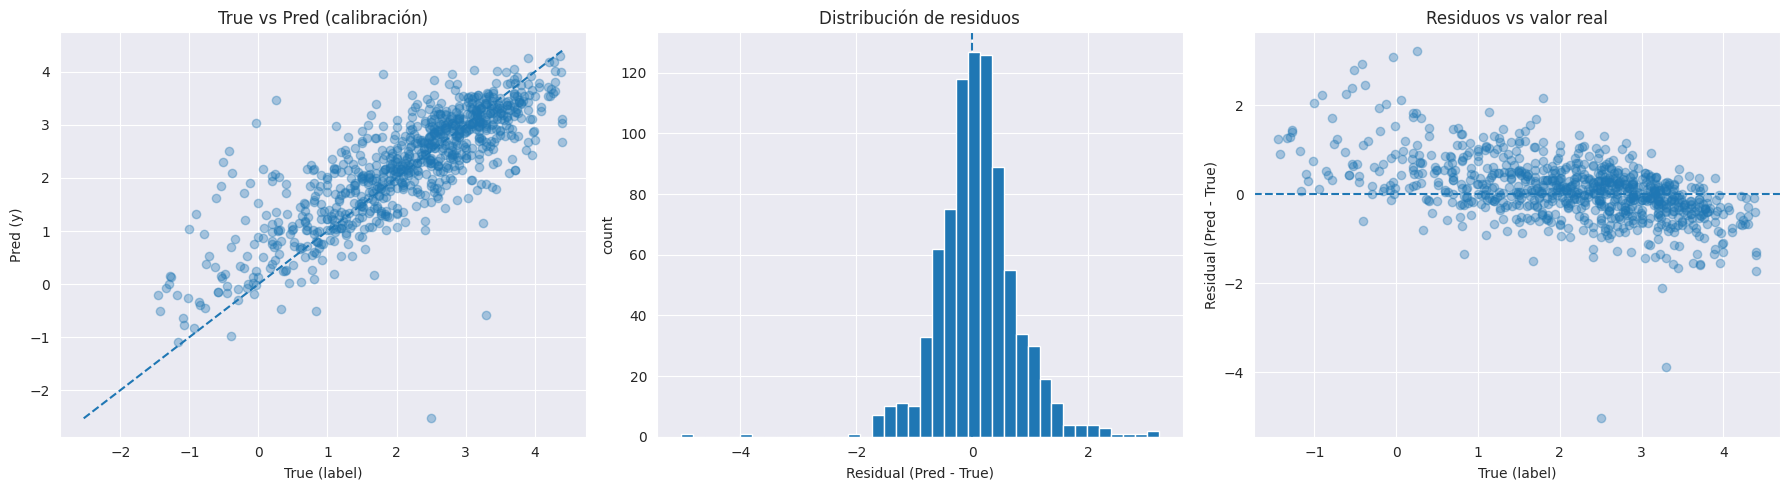

Top 15 outliers (mayor error absoluto):


,id,label,nid,y,residual,abs_err
830,2454,2.50,2454,-2.532040,-5.032040,5.032040
599,2240,3.30,2240,-0.589576,-3.889576,3.889576
609,2896,0.25,2896,3.478712,3.228712,3.228712
759,4199,-0.04,4199,3.042334,3.082334,3.082334
716,2820,-0.42,2820,2.505026,2.925026,2.925026
49,4103,-0.51,4103,2.293993,2.803993,2.803993
63,2319,-0.38,2319,2.085913,2.465913,2.465913
497,2670,-0.54,2670,1.845232,2.385232,2.385232
773,2081,-0.62,2081,1.629634,2.249634,2.249634
42,1770,-0.91,1770,1.312821,2.222821,2.222821


,label_bin,n,rmse,mae,bias
0,"(-1.4569999999999999, -0.475]",29,1.290631,1.075127,1.075127
1,"(-0.475, 0.5]",66,1.145535,0.856817,0.782739
2,"(0.5, 1.475]",132,0.672179,0.527264,0.349053
3,"(1.475, 2.45]",217,0.567096,0.426058,0.154719
4,"(2.45, 3.425]",288,0.624513,0.409505,-0.106441
5,"(3.425, 4.4]",108,0.670882,0.528976,-0.477941


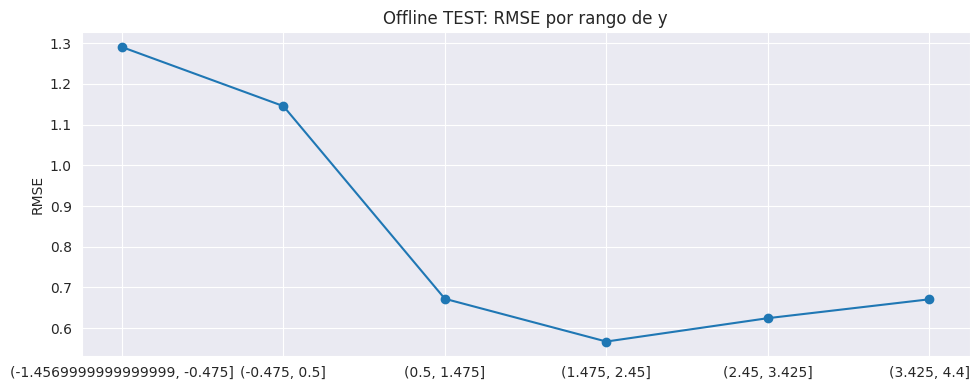

In [27]:
# Análisis de residuos (Offline TEST)
y_true = merged["label"].values.astype(float)
y_pred = merged["y"].values.astype(float)

# Residuo definido como (Pred - True)
res = y_pred - y_true

rmse_val = math.sqrt(mean_squared_error(y_true, y_pred))
mae_val  = mean_absolute_error(y_true, y_pred)
bias_val = float(np.mean(res))
std_res  = float(np.std(res))

print("Offline TEST metrics")
print(f"RMSE: {rmse_val:.4f}")
print(f"MAE : {mae_val:.4f}")
print(f"Bias (mean residual Pred-True): {bias_val:.4f}")
print(f"Residual std: {std_res:.4f}")


# Gráficas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True vs Pred (calibración)
axes[0].scatter(y_true, y_pred, alpha=0.35)
m = min(y_true.min(), y_pred.min())
M = max(y_true.max(), y_pred.max())
axes[0].plot([m, M], [m, M], linestyle="--")
axes[0].set_xlabel("True (label)")
axes[0].set_ylabel("Pred (y)")
axes[0].set_title("True vs Pred (calibración)")

# Histograma de residuos
axes[1].hist(res, bins=40)
axes[1].axvline(0, linestyle="--")
axes[1].set_xlabel("Residual (Pred - True)")
axes[1].set_ylabel("count")
axes[1].set_title("Distribución de residuos")

# Residuos vs True (heterocedasticidad)
axes[2].scatter(y_true, res, alpha=0.35)
axes[2].axhline(0, linestyle="--")
axes[2].set_xlabel("True (label)")
axes[2].set_ylabel("Residual (Pred - True)")
axes[2].set_title("Residuos vs valor real")

plt.tight_layout()
plt.show()


#Outliers: mayores errores absolutos

err_df = merged.copy()
err_df["residual"] = err_df["y"].astype(float) - err_df["label"].astype(float)
err_df["abs_err"]  = np.abs(err_df["residual"])

print("Top 15 outliers (mayor error absoluto):")
display(err_df.sort_values("abs_err", ascending=False).head(15))


# Error por rangos del target (bins)

err_df["label_bin"] = pd.cut(err_df["label"], bins=6, include_lowest=True)

grp = err_df.groupby("label_bin", observed=True).agg(
    n=("id", "count"),
    rmse=("residual", lambda e: float(np.sqrt(np.mean(np.array(e)**2)))),
    mae=("abs_err", "mean"),
    bias=("residual", "mean")
).reset_index()

display(grp)

# Plot RMSE por bin
plt.figure(figsize=(10, 4))
plt.plot(range(len(grp)), grp["rmse"].values, marker="o")
plt.xticks(range(len(grp)), grp["label_bin"].astype(str), rotation=0)
plt.ylabel("RMSE")
plt.title("Offline TEST: RMSE por rango de y")
plt.tight_layout()
plt.show()

El conjunto `test_labels.csv` no se utilizó en ningún momento para:

- Selección de arquitectura
- Ajuste de hiperparámetros
- Early stopping
- Elección del fold

El modelo fue completamente seleccionado mediante K-Fold Cross-Validation
sobre el conjunto de entrenamiento.

El análisis realizado sobre el Offline Test tiene únicamente carácter
diagnóstico y descriptivo (calibración, residuos, heterocedasticidad),
sin modificar posteriormente el modelo.

Por tanto, no existe data leakage ni sobreajuste inducido por el test.

# Conclusiones finales

Se demuestra que arquitecturas más expresivas como **GIN** y especialmente **GraphSAGE** superan claramente al baseline **GCN** en la predicción de lipofilicidad molecular.

El modelo final seleccionado para la solución del torneo fue **GraphSAGE (SAGE_mean)**, usando **ensemble** (promedio de modelos entrenados en los folds) para mejorar estabilidad y generalización.

Como trabajo futuro se propone:
- Normalización del target por fold (sin data leakage).
- Ajuste fino de hiperparámetros (hidden size, número de capas, dropout y LR).
- Pooling atencional moderno (`AttentionalAggregation`) y ensembles ponderados.